In [1]:
import sys
import math
import random
import os
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.lines import Line2D
from IPython.display import display, Image
print(sys.version)

3.11.12 (main, Apr  9 2025, 03:49:53) [Clang 20.1.0 ]


# Доп функции

In [2]:
def save_gif(history, path='assets/logistic_regression.gif', interval=300, step=1):
    """
    Сохраняет анимацию движения границы решения в GIF и выводит её в ноутбуке.

    history — список троек (w1, w2, b), по одной на итерацию обучения.
              Граница решения: w1*x1 + w2*x2 + b = 0
              Отсюда: x2 = -(w1*x1 + b) / w2
    step    — брать каждый N-й кадр.
    """
    os.makedirs(os.path.dirname(path), exist_ok=True)
    frames = history[::step]

    fig, ax = plt.subplots(figsize=(7, 5))

    def draw_frame(i):
        w1, w2, b = frames[i]
        ax.clear()

        for (x1, x2), label in zip(features, labels):
            color  = 'steelblue' if label == 1 else 'tomato'
            marker = 'o'         if label == 1 else 's'
            ax.scatter(x1, x2, color=color, marker=marker, s=70,
                       edgecolors='white', linewidths=0.5)

        x1_vals = [0, 11]
        if abs(w2) > 1e-9:
            x2_vals = [-(w1 * x + b) / w2 for x in x1_vals]
            ax.plot(x1_vals, x2_vals, color='purple', linewidth=2,
                    label=f'w1={w1:.2f}  w2={w2:.2f}  b={b:.2f}')

        ax.set_xlim(0, 11)
        ax.set_ylim(0, 11)
        ax.set_xlabel('Математика')
        ax.set_ylabel('Физика')
        ax.set_title(f'Итерация {i * step + 1}/{len(history)}')
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)

    anim = animation.FuncAnimation(fig, draw_frame, frames=len(frames), interval=interval)
    anim.save(path, writer='pillow')
    plt.close(fig)
    print(f'GIF сохранён: {path}  ({len(frames)} кадров из {len(history)})')
    display(Image(filename=path))

In [3]:
def plot_errors(histories, labels_list, title='Ошибка по эпохам', ylabel='Log Loss'):
    """
    Рисует график ошибки по эпохам для одного или нескольких методов.

    histories   — список списков ошибок, по одному на метод.
    labels_list — список названий методов.
    """
    plt.figure(figsize=(9, 4))
    for history, label in zip(histories, labels_list):
        plt.plot(history, linewidth=1.5, label=label)
    plt.xlabel('Эпоха')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Датасет

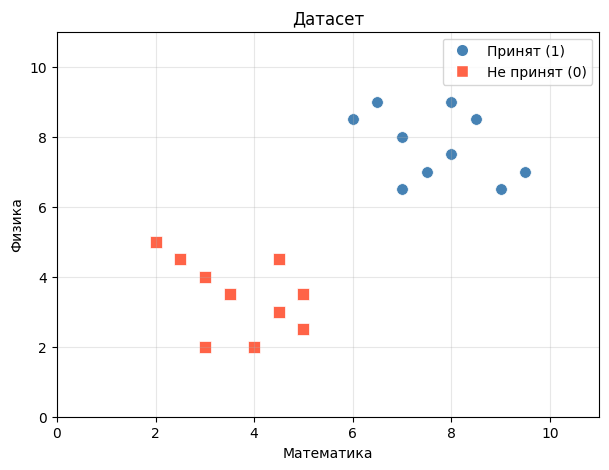

In [4]:
random.seed(7)

# x1 — балл за экзамен по математике, x2 — балл за экзамен по физике
# label: 1 — принят, 0 — не принят
data = [
    # принят (label=1)
    (8.0, 7.5, 1), (7.0, 8.0, 1), (9.0, 6.5, 1), (6.5, 9.0, 1),
    (8.5, 8.5, 1), (7.5, 7.0, 1), (9.5, 7.0, 1), (6.0, 8.5, 1),
    (8.0, 9.0, 1), (7.0, 6.5, 1),
    # не принят (label=0)
    (3.0, 4.0, 0), (4.5, 3.0, 0), (2.0, 5.0, 0), (5.0, 2.5, 0),
    (3.5, 3.5, 0), (4.0, 2.0, 0), (2.5, 4.5, 0), (5.0, 3.5, 0),
    (3.0, 2.0, 0), (4.5, 4.5, 0),
]

features = [(x1, x2) for x1, x2, _ in data]
labels   = [label for _, _, label in data]

plt.figure(figsize=(7, 5))
for (x1, x2), label in zip(features, labels):
    color  = 'steelblue' if label == 1 else 'tomato'
    marker = 'o'         if label == 1 else 's'
    plt.scatter(x1, x2, color=color, marker=marker, s=70, edgecolors='white', linewidths=0.5)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=9, label='Принят (1)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='tomato',    markersize=9, label='Не принят (0)'),
]
plt.legend(handles=legend_elements)
plt.xlabel('Математика')
plt.ylabel('Физика')
plt.title('Датасет')
plt.xlim(0, 11)
plt.ylim(0, 11)
plt.grid(True, alpha=0.3)
plt.show()

# Логистическая регрессия

Алгоритм классификации, похожий на дискретный перцептрон, но вместо класса 0/1 возвращает **вероятность** принадлежности к классу 1.

Формула модели та же: `score = w1*x1 + w2*x2 + b`

Отличия от перцептрона — в трёх компонентах: функция активации, функция ошибки, правило обновления весов.

---

## Функция активации — сигмоида

Преобразует `score` (любое число) в диапазон (0, 1):

`σ(x) = 1 / (1 + e^(-x))`

Результат интерпретируется как вероятность принадлежности точки к классу 1.

---

## Функция ошибки — Log Loss

Нельзя просто взять разность `y - ŷ`, потому что для оценки общей ошибки по датасету нужно **перемножать** вероятности (правило произведения для независимых событий). Произведение многих малых чисел (1) вычислительно нестабильно и (2) быстро стремится к нулю.

Логарифм превращает произведение в сумму: `log(a · b) = log(a) + log(b)`.

Ошибка для одной точки:

`loss = -y · ln(ŷ) - (1 - y) · ln(1 - ŷ)`

- Если `y=1`: берём `ln(ŷ)` — уверенность модели в классе 1
- Если `y=0`: берём `ln(1 - ŷ)` — уверенность модели в классе 0

Log Loss не сводится к нулю и хуже поддаётся прямой интерпретации чем MAE/RMSE — удобен для отслеживания тренда обучения.

---

## Обновление весов

Производная Log Loss даёт те же формулы, что у перцептрона:

```
w += learning_rate * x * (y - ŷ)
b += learning_rate * (y - ŷ)
```

Отличие от перцептрона: `(y - ŷ)` — не бинарное (-1/0/+1), а вещественное число. Поэтому:
- Если точка **ошибочна** — большой шаг (ŷ далеко от y)
- Если точка **верна** — малый шаг, постепенно увеличивающий уверенность (ŷ сдвигается ближе к 0 или 1)

---

## Softmax (обобщение на много классов)

Для K классов вместо сигмоиды используется softmax:

`P(класс k) = e^(score_k) / Σ e^(score_i)`

Экспонента делает все значения положительными, деление нормирует их в вероятности. Сигмоида — частный случай softmax для двух классов.

In [5]:
random.seed(42)
epochs        = 1000
learning_rate = 0.2

w1, w2, b      = 1.0, 1.0, 0.0
error_history  = []
params_history = []

def score_model(x1, x2, w1, w2, b):
    return w1*x1 + w2*x2 + b

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def get_predict(x1, x2):
    return sigmoid(score_model(x1, x2, w1, w2, b))

def log_loss(y, y_pred):
    return -y * math.log(y_pred) - (1 - y) * math.log(1 - y_pred)

for epoch in range(epochs):
    total_loss = sum(log_loss(y, get_predict(x1, x2)) for x1, x2, y in data)
    error_history.append(total_loss)
    params_history.append((w1, w2, b))

    x1, x2, y = data[random.randint(0, len(data) - 1)]
    y_pred = get_predict(x1, x2)
    error  = y - y_pred

    # Градиент Log Loss: производная по w = -error * x, по b = -error
    # Шаг пропорционален ошибке: чем дальше ŷ от y, тем больше сдвиг
    w1 += learning_rate * x1 * error
    w2 += learning_rate * x2 * error
    b  += learning_rate * error

    if epoch % 100 == 0:
        print(f"{epoch=} {total_loss=:.2f}")

epoch=0 total_loss=71.51
epoch=100 total_loss=82.69
epoch=200 total_loss=16.48
epoch=300 total_loss=5.30
epoch=400 total_loss=3.35
epoch=500 total_loss=0.92
epoch=600 total_loss=2.73
epoch=700 total_loss=0.79
epoch=800 total_loss=1.28
epoch=900 total_loss=1.29


GIF сохранён: assets/logistic_regression.gif  (67 кадров из 1000)


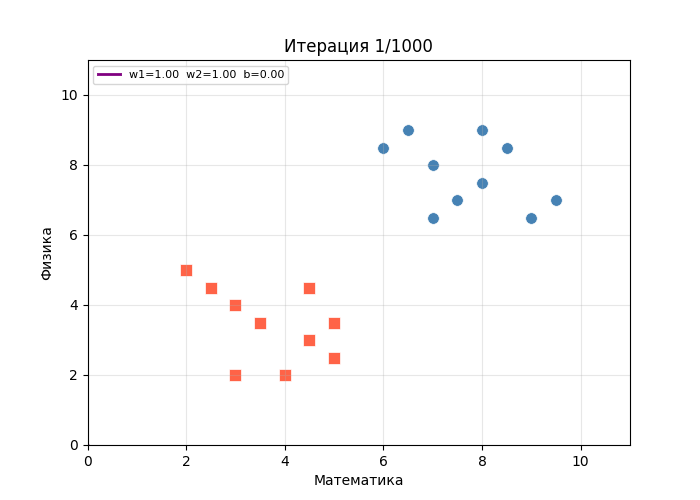

In [6]:
save_gif(params_history, path='assets/logistic_regression.gif', interval=300, step=15)

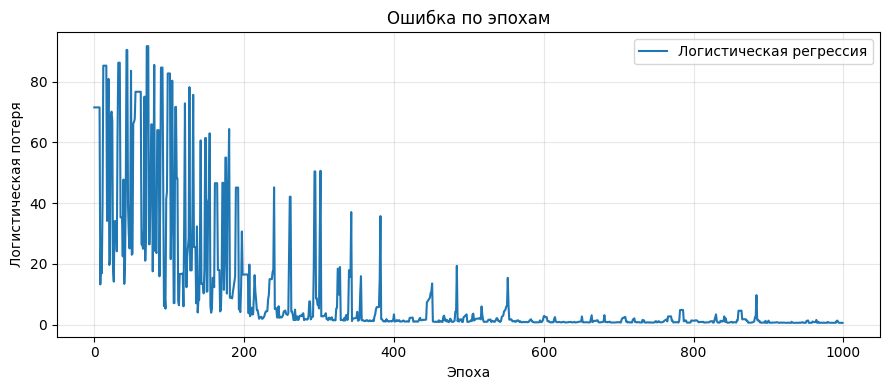

In [7]:
plot_errors([error_history], ['Логистическая регрессия'], ylabel='Логистическая потеря')